# Coastal Water Quality Analysis and HMM-LSTM Forecasting

This notebook implements a Hybrid HMM-LSTM model for 7-day water quality forecasting based on coastal water quality data.

## Model Architecture
- **HMM Layer**: Extracts hidden states from time series using Dense + Tanh
- **Branch 1**: LSTM-1 (128) → LSTM-2 (64) → Attention Layer
- **Branch 2**: LSTM-3 (64) for comparative learning
- **Concatenation**: Combines both branches
- **Dense Layers**: Dense(64) → Dense(32) → Output(softmax)

## Features
- TSS (Total Suspended Solids)
- PH (pH level)
- TPH (Total Petroleum Hydrocarbons)
- Total_Coliform
- DO (Dissolved Oxygen)

## Target
- Water_Quality: 1 (Good), 2 (Moderate), 3+ (Poor)

## 1. Setup and Installation

In [ ]:
# Install required packages
!pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn hmmlearn plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Concatenate,
    Attention, TimeDistributed, Activation
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Scikit-learn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

# HMM
from hmmlearn import hmm

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: []


## 2. Data Loading and Exploration

In [ ]:
# Load dataset
# Upload your water_quality_hmm_lstm_training_data_ver_1_0.csv file to Colab
from google.colab import files
uploaded = files.upload()

Saving water_quality_hmm_lstm_training_data_ver_1.0.csv to water_quality_hmm_lstm_training_data_ver_1.0.csv


In [ ]:
# Read the data
df = pd.read_csv('water_quality_hmm_lstm_training_data_ver_1.0.csv')

# Basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
display(df.head(10))

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe())

Dataset Shape: (1305, 9)

First few rows:


,time,TSS,PH,TPH,Total_Coliform,DO,Water_Quality,WQL_EN,WQL_VI
0,1/1/2020,39.15,8.20,0.74,84,4.80,2,Moderate,Trung bình
1,1/2/2020,56.92,8.02,0.50,59,4.74,2,Moderate,Trung bình
2,1/3/2020,6.20,7.80,0.21,0,5.01,1,Good,Tốt
3,1/6/2020,14.28,8.33,0.28,117,4.28,2,Moderate,Trung bình
4,1/7/2020,42.70,7.89,0.44,45,4.75,2,Moderate,Trung bình
5,1/8/2020,74.72,8.08,0.10,198,4.37,2,Moderate,Trung bình
6,1/9/2020,5.31,7.87,0.40,189,4.95,1,Good,Tốt
7,1/10/2020,35.54,7.84,0.17,60,5.30,1,Good,Tốt
8,1/13/2020,9.07,8.15,0.26,36,5.13,1,Good,Tốt
9,1/14/2020,59.39,7.95,0.28,145,5.30,2,Moderate,Trung bình



Data Types:
time               object
TSS               float64
PH                float64
TPH               float64
Total_Coliform      int64
DO                float64
Water_Quality       int64
WQL_EN             object
WQL_VI             object
dtype: object

Missing Values:
time              0
TSS               0
PH                0
TPH               0
Total_Coliform    0
DO                0
Water_Quality     0
WQL_EN            0
WQL_VI            0
dtype: int64

Basic Statistics:


,TSS,PH,TPH,Total_Coliform,DO,Water_Quality
count,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000,1305.000000
mean,28.391739,8.192015,0.338667,3768.443678,5.101318,2.048276
std,19.077397,0.170918,0.208879,10114.931673,0.716761,0.499968
min,0.000000,7.550000,0.100000,0.000000,3.500000,1.000000
25%,14.470000,8.090000,0.150000,99.000000,4.640000,2.000000
50%,22.240000,8.220000,0.310000,338.000000,5.030000,2.000000
75%,40.610000,8.320000,0.470000,3341.000000,5.480000,2.000000
max,100.090000,8.600000,1.240000,144686.000000,7.840000,3.000000


In [ ]:
# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'], format='%m/%d/%Y')
df = df.sort_values('time').reset_index(drop=True)

# Feature columns
feature_cols = ['TSS', 'PH', 'TPH', 'Total_Coliform', 'DO']
target_col = 'Water_Quality'

print("Date Range:", df['time'].min(), "to", df['time'].max())
print("Total Days:", (df['time'].max() - df['time'].min()).days)
print("\nWater Quality Distribution:")
print(df[target_col].value_counts().sort_index())
print("\nWater Quality Labels:")
print(df[['Water_Quality', 'WQL_EN']].drop_duplicates().sort_values('Water_Quality'))

Date Range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00
Total Days: 1826

Water Quality Distribution:
Water_Quality
1    133
2    976
3    196
Name: count, dtype: int64

Water Quality Labels:
    Water_Quality    WQL_EN
2               1      Good
0               2  Moderate
58              3       Bad


## 3. Exploratory Data Analysis

In [ ]:
# Time series visualization of all features
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=('TSS Over Time', 'PH Over Time',
                    'TPH Over Time', 'Total Coliform Over Time',
                    'DO Over Time', 'Water Quality Over Time'),
    vertical_spacing=0.12
)

# TSS
fig.add_trace(go.Scatter(x=df['time'], y=df['TSS'], mode='lines', name='TSS',
                        line=dict(color='blue')), row=1, col=1)

# PH
fig.add_trace(go.Scatter(x=df['time'], y=df['PH'], mode='lines', name='PH',
                        line=dict(color='green')), row=1, col=2)

# TPH
fig.add_trace(go.Scatter(x=df['time'], y=df['TPH'], mode='lines', name='TPH',
                        line=dict(color='red')), row=2, col=1)

# Total Coliform
fig.add_trace(go.Scatter(x=df['time'], y=df['Total_Coliform'], mode='lines',
                        name='Total Coliform', line=dict(color='purple')), row=2, col=2)

# DO
fig.add_trace(go.Scatter(x=df['time'], y=df['DO'], mode='lines', name='DO',
                        line=dict(color='orange')), row=3, col=1)

# Water Quality
fig.add_trace(go.Scatter(x=df['time'], y=df['Water_Quality'], mode='markers+lines',
                        name='Water Quality', line=dict(color='black')), row=3, col=2)

fig.update_layout(height=900, showlegend=False, title_text="Water Quality Parameters Over Time")
fig.show()

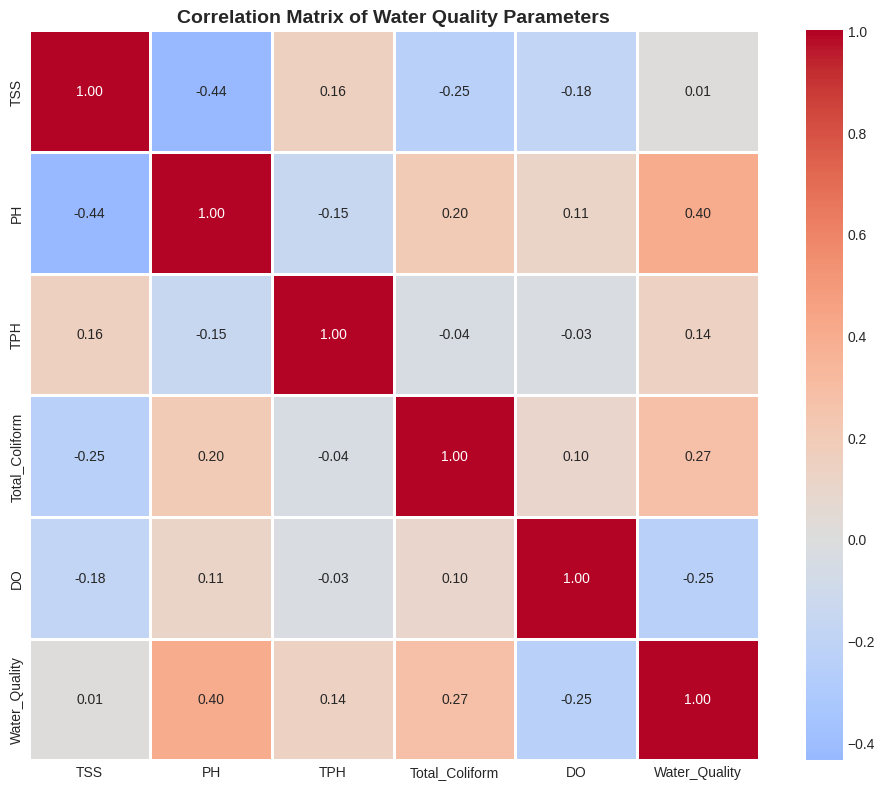

In [ ]:
# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df[feature_cols + [target_col]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Water Quality Parameters', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

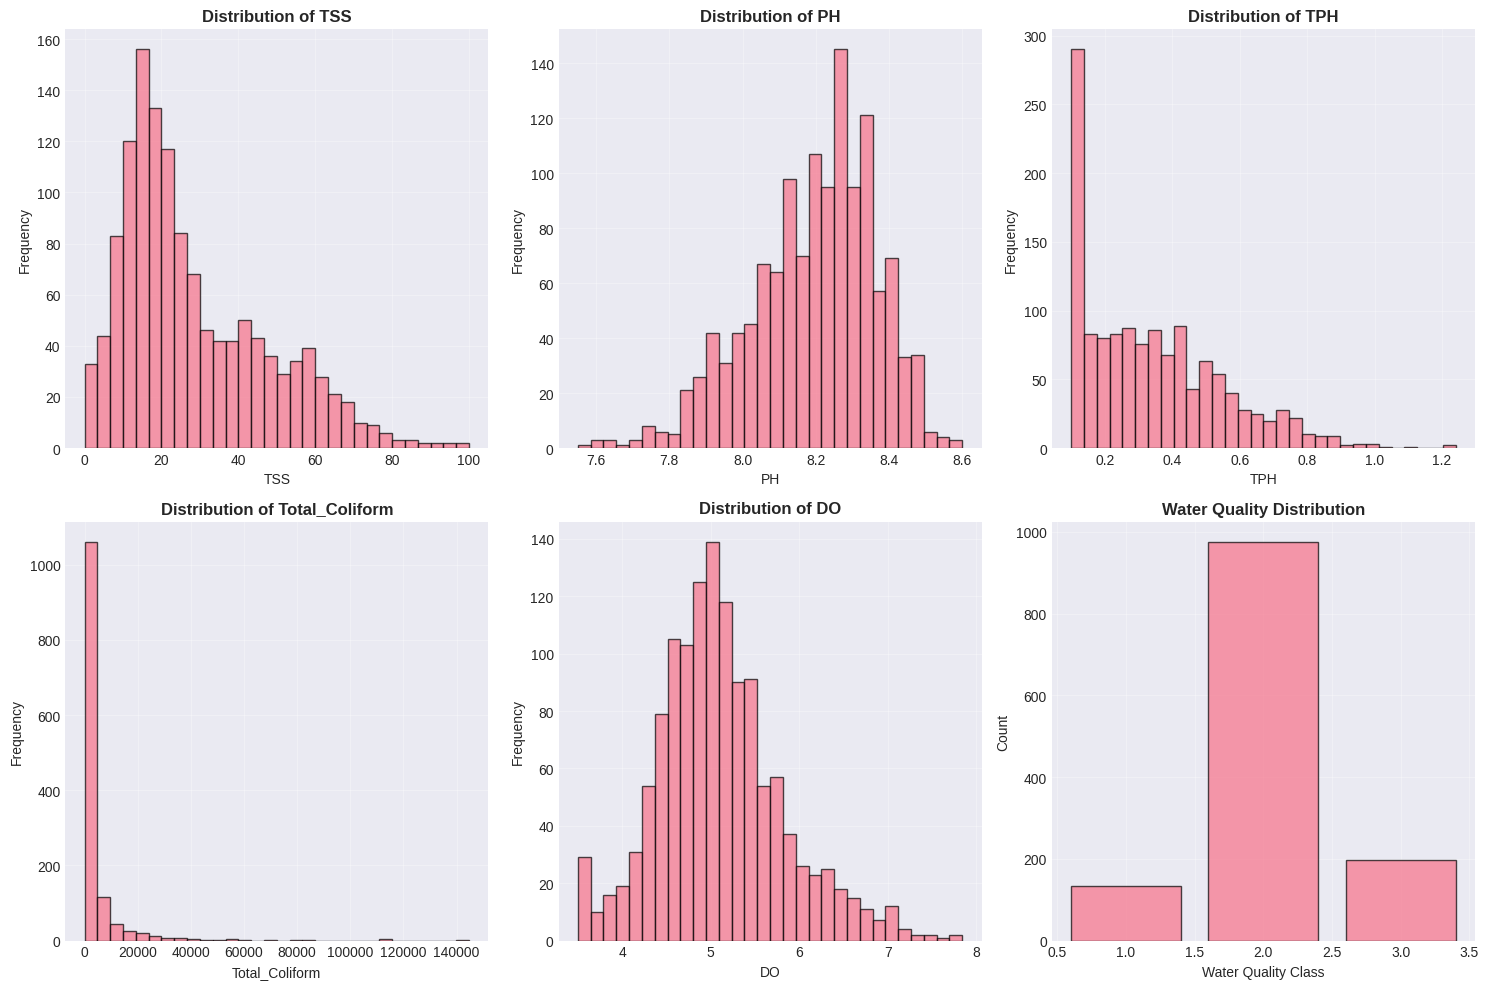

In [ ]:
# Distribution plots for each feature
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, weight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Water quality distribution
water_quality_counts = df[target_col].value_counts().sort_index()
axes[5].bar(water_quality_counts.index, water_quality_counts.values,
            edgecolor='black', alpha=0.7)
axes[5].set_title('Water Quality Distribution', fontsize=12, weight='bold')
axes[5].set_xlabel('Water Quality Class')
axes[5].set_ylabel('Count')
axes[5].grid(alpha=0.3)

plt.tight_layout()
plt.show()

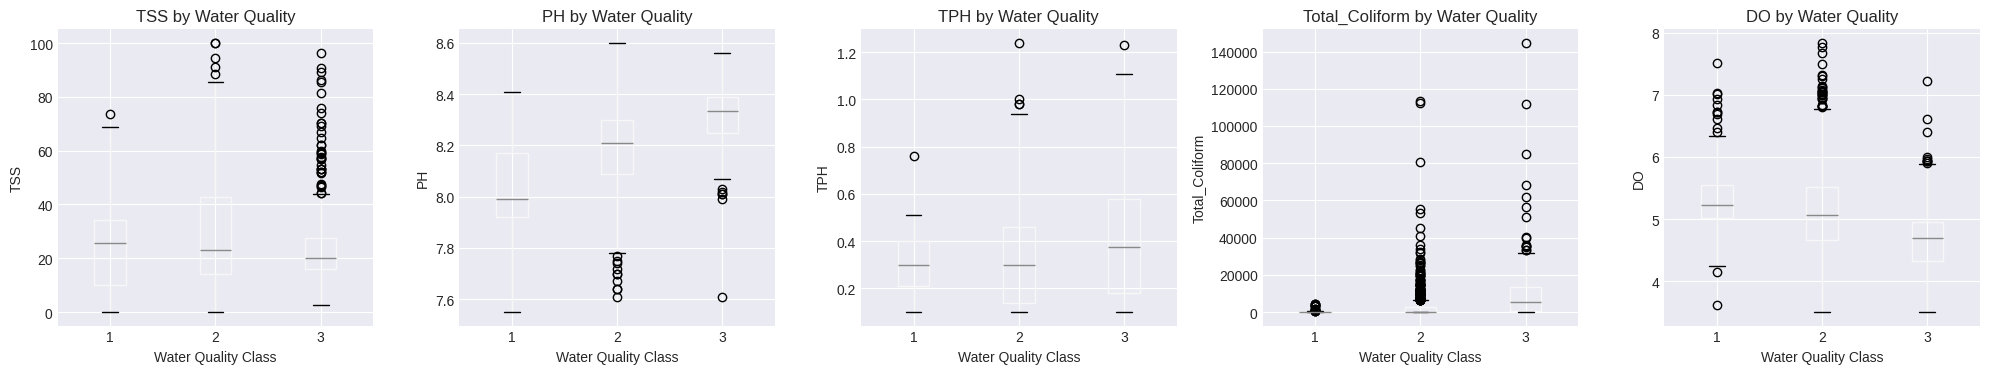

In [ ]:
# Box plots by water quality class
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, col in enumerate(feature_cols):
    df.boxplot(column=col, by=target_col, ax=axes[idx])
    axes[idx].set_title(f'{col} by Water Quality')
    axes[idx].set_xlabel('Water Quality Class')
    axes[idx].set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

## 4. Trend Analysis - Short-term and Long-term

In [ ]:
# Calculate rolling statistics for trend analysis
df_trends = df.copy()
df_trends = df_trends.set_index('time')

# Short-term trends (7-day moving average)
# Long-term trends (30-day moving average)
for col in feature_cols:
    df_trends[f'{col}_MA7'] = df_trends[col].rolling(window=7, min_periods=1).mean()
    df_trends[f'{col}_MA30'] = df_trends[col].rolling(window=30, min_periods=1).mean()
    df_trends[f'{col}_STD7'] = df_trends[col].rolling(window=7, min_periods=1).std()

print("Trend features calculated successfully!")
display(df_trends.head())

Trend features calculated successfully!


,TSS,PH,TPH,Total_Coliform,DO,Water_Quality,WQL_EN,WQL_VI,TSS_MA7,TSS_MA30,TSS_STD7,PH_MA7,PH_MA30,PH_STD7,TPH_MA7,TPH_MA30,TPH_STD7,Total_Coliform_MA7,Total_Coliform_MA30,Total_Coliform_STD7,DO_MA7,DO_MA30,DO_STD7
time,,,,,,,,,,,,,,,,,,,,,,,
2020-01-01,39.15,8.20,0.74,84,4.80,2,Moderate,Trung bình,39.1500,39.1500,NaN,8.200000,8.200000,NaN,0.740000,0.740000,NaN,84.000000,84.000000,NaN,4.8000,4.8000,NaN
2020-01-02,56.92,8.02,0.50,59,4.74,2,Moderate,Trung bình,48.0350,48.0350,12.565288,8.110000,8.110000,0.127279,0.620000,0.620000,0.169706,71.500000,71.500000,17.677670,4.7700,4.7700,0.042426
2020-01-03,6.20,7.80,0.21,0,5.01,1,Good,Tốt,34.0900,34.0900,25.735817,8.006667,8.006667,0.200333,0.483333,0.483333,0.265393,47.666667,47.666667,43.131582,4.8500,4.8500,0.141774
2020-01-06,14.28,8.33,0.28,117,4.28,2,Moderate,Trung bình,29.1375,29.1375,23.230667,8.087500,8.087500,0.229982,0.432500,0.432500,0.239357,65.000000,65.000000,49.416596,4.7075,4.7075,0.307612
2020-01-07,42.70,7.89,0.44,45,4.75,2,Moderate,Trung bình,31.8500,31.8500,21.012763,8.048000,8.048000,0.217876,0.434000,0.434000,0.207316,61.000000,61.000000,43.720704,4.7160,4.7160,0.267077


In [ ]:
# Visualize short-term vs long-term trends
fig = make_subplots(
    rows=5, cols=1,
    subplot_titles=[f'{col} - Short-term (7d) vs Long-term (30d) Trends' for col in feature_cols],
    vertical_spacing=0.08
)

for idx, col in enumerate(feature_cols, 1):
    # Original data
    fig.add_trace(go.Scatter(
        x=df_trends.index, y=df_trends[col],
        mode='markers', name=f'{col} (Raw)',
        marker=dict(size=3, opacity=0.3),
        showlegend=(idx==1)
    ), row=idx, col=1)

    # 7-day MA (short-term)
    fig.add_trace(go.Scatter(
        x=df_trends.index, y=df_trends[f'{col}_MA7'],
        mode='lines', name='7-day MA',
        line=dict(color='blue', width=2),
        showlegend=(idx==1)
    ), row=idx, col=1)

    # 30-day MA (long-term)
    fig.add_trace(go.Scatter(
        x=df_trends.index, y=df_trends[f'{col}_MA30'],
        mode='lines', name='30-day MA',
        line=dict(color='red', width=2),
        showlegend=(idx==1)
    ), row=idx, col=1)

fig.update_layout(height=1200, title_text="Short-term and Long-term Trend Analysis")
fig.show()

In [ ]:
# Seasonal decomposition and trend statistics
print("=" * 80)
print("TREND ANALYSIS SUMMARY")
print("=" * 80)

for col in feature_cols:
    print(f"\n{col}:")
    print("-" * 40)

    # Short-term volatility (7-day std)
    short_term_vol = df_trends[f'{col}_STD7'].mean()

    # Long-term trend direction
    trend_slope = (df_trends[f'{col}_MA30'].iloc[-1] - df_trends[f'{col}_MA30'].iloc[0]) / len(df_trends)

    print(f"  Average short-term volatility (7d): {short_term_vol:.4f}")
    print(f"  Long-term trend slope (30d): {trend_slope:.6f}")
    print(f"  Overall mean: {df_trends[col].mean():.4f}")
    print(f"  Overall std: {df_trends[col].std():.4f}")

    if trend_slope > 0:
        print(f"  → Increasing trend detected")
    elif trend_slope < 0:
        print(f"  → Decreasing trend detected")
    else:
        print(f"  → Stable trend")

TREND ANALYSIS SUMMARY

TSS:
----------------------------------------
  Average short-term volatility (7d): 12.0438
  Long-term trend slope (30d): -0.001397
  Overall mean: 28.3917
  Overall std: 19.0774
  → Decreasing trend detected

PH:
----------------------------------------
  Average short-term volatility (7d): 0.1307
  Long-term trend slope (30d): 0.000017
  Overall mean: 8.1920
  Overall std: 0.1709
  → Increasing trend detected

TPH:
----------------------------------------
  Average short-term volatility (7d): 0.1916
  Long-term trend slope (30d): -0.000316
  Overall mean: 0.3387
  Overall std: 0.2089
  → Decreasing trend detected

Total_Coliform:
----------------------------------------
  Average short-term volatility (7d): 4825.7870
  Long-term trend slope (30d): 0.008225
  Overall mean: 3768.4437
  Overall std: 10114.9317
  → Increasing trend detected

DO:
----------------------------------------
  Average short-term volatility (7d): 0.6104
  Long-term trend slope (30d): -0

## 5. Data Preprocessing for HMM-LSTM

In [ ]:
# Prepare data for modeling
df_model = df[['time'] + feature_cols + [target_col]].copy()

# Handle any missing values
df_model = df_model.fillna(method='ffill').fillna(method='bfill')

# Separate features and target
X = df_model[feature_cols].values
y = df_model[target_col].values - 1  # Convert to 0-indexed (0: Good, 1: Moderate, 2+: Poor)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature shape:", X_scaled.shape)
print("Target shape:", y.shape)
print("Target classes:", np.unique(y))
print("\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} samples ({c/len(y)*100:.1f}%)")

Feature shape: (1305, 5)
Target shape: (1305,)
Target classes: [0 1 2]

Class distribution:
  Class 0: 133 samples (10.2%)
  Class 1: 976 samples (74.8%)
  Class 2: 196 samples (15.0%)


In [ ]:
# Create sequences for time series modeling
def create_sequences(X, y, time_steps=7):
    """
    Create sequences for time series prediction

    Args:
        X: Input features
        y: Target labels
        time_steps: Number of time steps to look back

    Returns:
        X_seq: Sequences of features
        y_seq: Corresponding labels
    """
    X_seq, y_seq = [], []

    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])

    return np.array(X_seq), np.array(y_seq)

# Create sequences with 7-day lookback
TIME_STEPS = 7
X_seq, y_seq = create_sequences(X_scaled, y, TIME_STEPS)

print(f"Sequence shape: {X_seq.shape}")
print(f"Target shape: {y_seq.shape}")
print(f"Sample sequence shape: (time_steps={TIME_STEPS}, features={len(feature_cols)})")

Sequence shape: (1298, 7, 5)
Target shape: (1298,)
Sample sequence shape: (time_steps=7, features=5)


In [ ]:
# Split data into train, validation, and test sets
# Use temporal split to maintain time series integrity
train_size = int(0.7 * len(X_seq))
val_size = int(0.15 * len(X_seq))

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]

X_val = X_seq[train_size:train_size + val_size]
y_val = y_seq[train_size:train_size + val_size]

X_test = X_seq[train_size + val_size:]
y_test = y_seq[train_size + val_size:]

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

# Convert to categorical for multi-class classification
n_classes = len(np.unique(y))
y_train_cat = keras.utils.to_categorical(y_train, n_classes)
y_val_cat = keras.utils.to_categorical(y_val, n_classes)
y_test_cat = keras.utils.to_categorical(y_test, n_classes)

print(f"\nNumber of classes: {n_classes}")

Training set: (908, 7, 5) (908,)
Validation set: (194, 7, 5) (194,)
Test set: (196, 7, 5) (196,)

Number of classes: 3


## 6. HMM Feature Engineering

In [ ]:
# Extract HMM hidden states as additional features
def extract_hmm_features(X, n_states=3):
    """
    Use HMM to extract hidden states from time series data

    Args:
        X: Input sequences (samples, time_steps, features)
        n_states: Number of hidden states

    Returns:
        hmm_features: Predicted hidden states
    """
    # Reshape for HMM (combine all sequences)
    X_flat = X.reshape(-1, X.shape[-1])

    # Train Gaussian HMM
    model = hmm.GaussianHMM(
        n_components=n_states,
        covariance_type='full',
        n_iter=100,
        random_state=42
    )

    model.fit(X_flat)

    # Predict hidden states
    hidden_states = model.predict(X_flat)

    # Reshape back to sequences
    hidden_states_seq = hidden_states.reshape(X.shape[0], X.shape[1])

    # One-hot encode hidden states
    hidden_states_onehot = keras.utils.to_categorical(hidden_states_seq, n_states)

    return hidden_states_onehot, model

# Extract HMM features
print("Extracting HMM hidden states...")
N_HMM_STATES = 3
hmm_train, hmm_model = extract_hmm_features(X_train, N_HMM_STATES)

# For validation and test, use the trained HMM model
X_val_flat = X_val.reshape(-1, X_val.shape[-1])
hmm_val_states = hmm_model.predict(X_val_flat).reshape(X_val.shape[0], X_val.shape[1])
hmm_val = keras.utils.to_categorical(hmm_val_states, N_HMM_STATES)

X_test_flat = X_test.reshape(-1, X_test.shape[-1])
hmm_test_states = hmm_model.predict(X_test_flat).reshape(X_test.shape[0], X_test.shape[1])
hmm_test = keras.utils.to_categorical(hmm_test_states, N_HMM_STATES)

print(f"HMM features shape: {hmm_train.shape}")
print(f"HMM states distribution (train):")
unique, counts = np.unique(hmm_model.predict(X_train.reshape(-1, X_train.shape[-1])), return_counts=True)
for u, c in zip(unique, counts):
    print(f"  State {u}: {c} ({c/len(X_train.reshape(-1, X_train.shape[-1]))*100:.1f}%)")

Extracting HMM hidden states...
HMM features shape: (908, 7, 3)
HMM states distribution (train):
  State 0: 645 (10.1%)
  State 1: 2400 (37.8%)
  State 2: 3311 (52.1%)


## 7. Build Hybrid HMM-LSTM Model

In [ ]:
# Custom Attention Layer
class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs shape: (batch_size, time_steps, features)
        e = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        e = tf.reduce_sum(e, axis=-1, keepdims=True)
        alpha = tf.nn.softmax(e, axis=1)
        output = inputs * alpha
        return tf.reduce_sum(output, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

In [ ]:
def build_hmm_lstm_model(time_steps, n_features, n_hmm_states, n_classes):
    """
    Build the Hybrid HMM-LSTM-Attention model

    Architecture:
    - Input Layer (Time Series)
    - HMM States (Dense + Tanh)
    - Branch 1: LSTM-1 (128) → LSTM-2 (64) → Attention Layer
    - Branch 2: LSTM-3 (64)
    - Concatenate
    - Dense (64) + ReLU + Dropout(0.3)
    - Dense (32) + ReLU + Dropout(0.2)
    - Output (Softmax)
    """

    # Input layers
    input_ts = Input(shape=(time_steps, n_features), name='time_series_input')
    input_hmm = Input(shape=(time_steps, n_hmm_states), name='hmm_states_input')

    # HMM States processing (Dense + Tanh)
    hmm_processed = TimeDistributed(Dense(64, activation='tanh'))(input_hmm)

    # Concatenate time series with HMM features
    combined_input = Concatenate(axis=-1)([input_ts, hmm_processed])

    # Branch 1: LSTM + Attention
    lstm1 = LSTM(128, return_sequences=True, name='LSTM_1')(combined_input)
    dropout1 = Dropout(0.3)(lstm1)

    lstm2 = LSTM(64, return_sequences=True, name='LSTM_2')(dropout1)
    dropout2 = Dropout(0.3)(lstm2)

    attention_output = AttentionLayer(name='Attention_Layer')(dropout2)

    # Branch 2: LSTM only
    lstm3 = LSTM(64, return_sequences=False, name='LSTM_3')(combined_input)
    dropout3 = Dropout(0.3)(lstm3)

    # Concatenate both branches
    concatenated = Concatenate(name='Concatenate')([attention_output, dropout3])

    # Dense layers
    dense1 = Dense(64, activation='relu', name='Dense_1')(concatenated)
    dropout4 = Dropout(0.3)(dense1)

    dense2 = Dense(32, activation='relu', name='Dense_2')(dropout4)
    dropout5 = Dropout(0.2)(dense2)

    # Output layer
    output = Dense(n_classes, activation='softmax', name='Output')(dropout5)

    # Build model
    model = Model(inputs=[input_ts, input_hmm], outputs=output, name='HMM_LSTM_Attention')

    return model

Model: "HMM_LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hmm_states_input    │ (None, 7, 3)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_series_input   │ (None, 7, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 7, 64)     │        256 │ hmm_states_input… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 69)     │          0 │ time_series_inpu… │
│ (Concatenate)       │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_1 (LSTM)       │ (None, 7, 128)    │    101,376 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 7, 128)    │          0 │ LSTM_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_2 (LSTM)       │ (None, 7, 64)     │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 7, 64)     │          0 │ LSTM_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LSTM_3 (LSTM)       │ (None, 64)        │     34,304 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention_Layer     │ (None, 64)        │      4,160 │ dropout_1[0][0]   │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ LSTM_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concatenate         │ (None, 128)       │          0 │ Attention_Layer[… │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_1 (Dense)     │ (None, 64)        │      8,256 │ Concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ Dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ Dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output (Dense)      │ (None, 3)         │         99 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 199,939 (781.01 KB)

 Trainable params: 199,939 (781.01 KB)

 Non-trainable params: 0 (0.00 B)

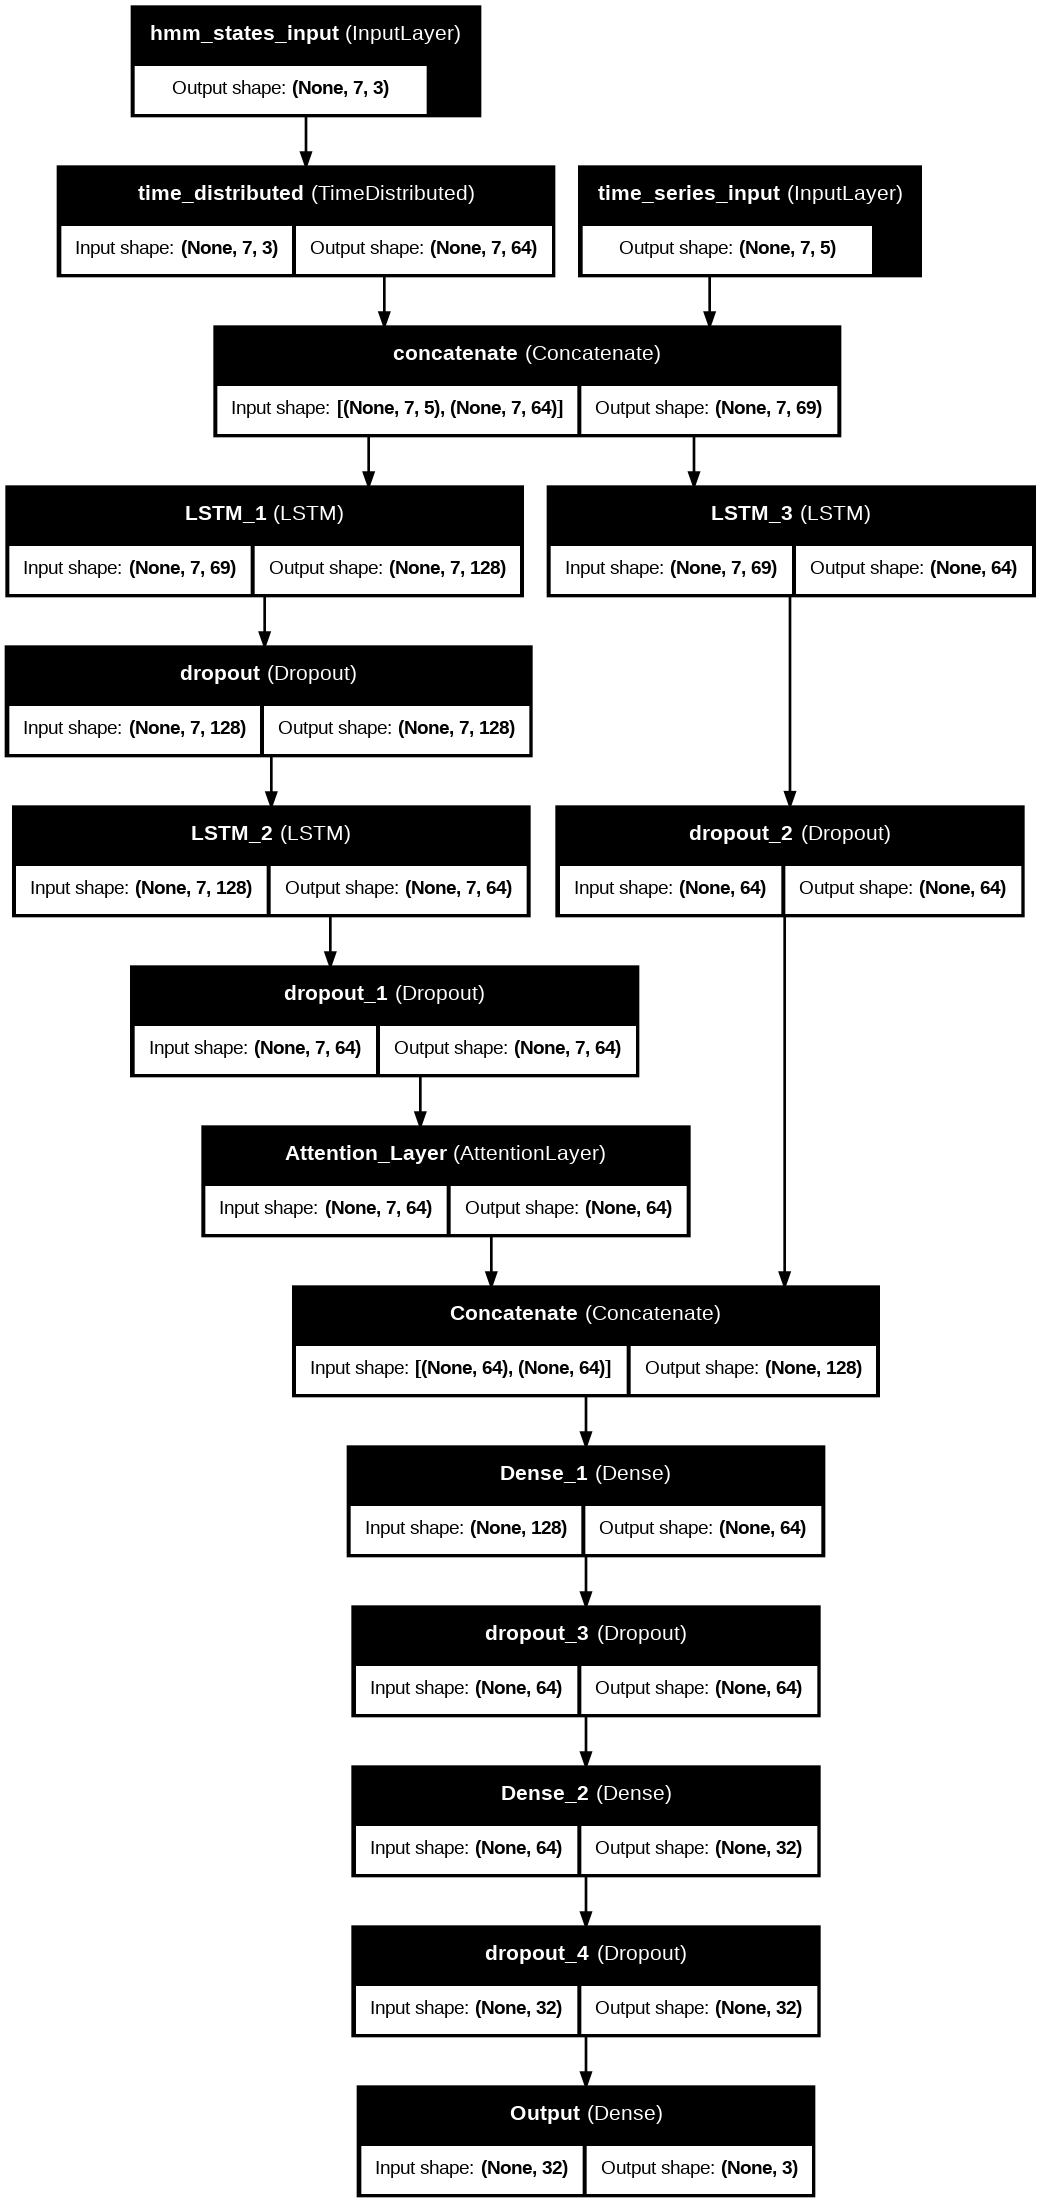

In [ ]:
# Build the model
model = build_hmm_lstm_model(
    time_steps=TIME_STEPS,
    n_features=len(feature_cols),
    n_hmm_states=N_HMM_STATES,
    n_classes=n_classes
)

# Model summary
model.summary()

# Visualize model architecture
keras.utils.plot_model(
    model,
    to_file='hmm_lstm_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=96
)

from IPython.display import Image
Image('hmm_lstm_architecture.png')

## 8. Model Training

In [ ]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_hmm_lstm_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, checkpoint]

In [ ]:
# Train the model
print("Starting model training...")
print("=" * 80)

history = model.fit(
    [X_train, hmm_train],
    y_train_cat,
    validation_data=([X_val, hmm_val], y_val_cat),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Starting model training...
Epoch 1/100
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6655 - loss: 0.9292 - precision: 0.6633 - recall: 0.3097
Epoch 1: val_accuracy improved from -inf to 0.78866, saving model to best_hmm_lstm_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.6691 - loss: 0.9242 - precision: 0.6683 - recall: 0.3250 - val_accuracy: 0.7887 - val_loss: 0.6815 - val_precision: 0.7887 - val_recall: 0.7887 - learning_rate: 0.0010
Epoch 2/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7572 - loss: 0.7351 - precision: 0.7716 - recall: 0.7263
Epoch 2: val_accuracy did not improve from 0.78866
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7564 - loss: 0.7367 - precision: 0.7701 - recall: 0.7267 - val_accuracy: 0.7887 - val_loss: 0.6460 - val_precision: 0.7887 - val_recall: 0.7887 - learning_rate: 0.0010
Epoch 3/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7570 - loss: 0.7317 - precision: 0.7592 - recall: 0.7327
Epoch 3: val_accuracy did not improve from 0.78866
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7560 - loss: 0.7315 - precision: 0.7580 - recall: 0.7326 - val_accuracy: 0.7887 - val_loss: 0.6327 - val_precision: 0.7887 - val_recall: 0.7887 - learnin

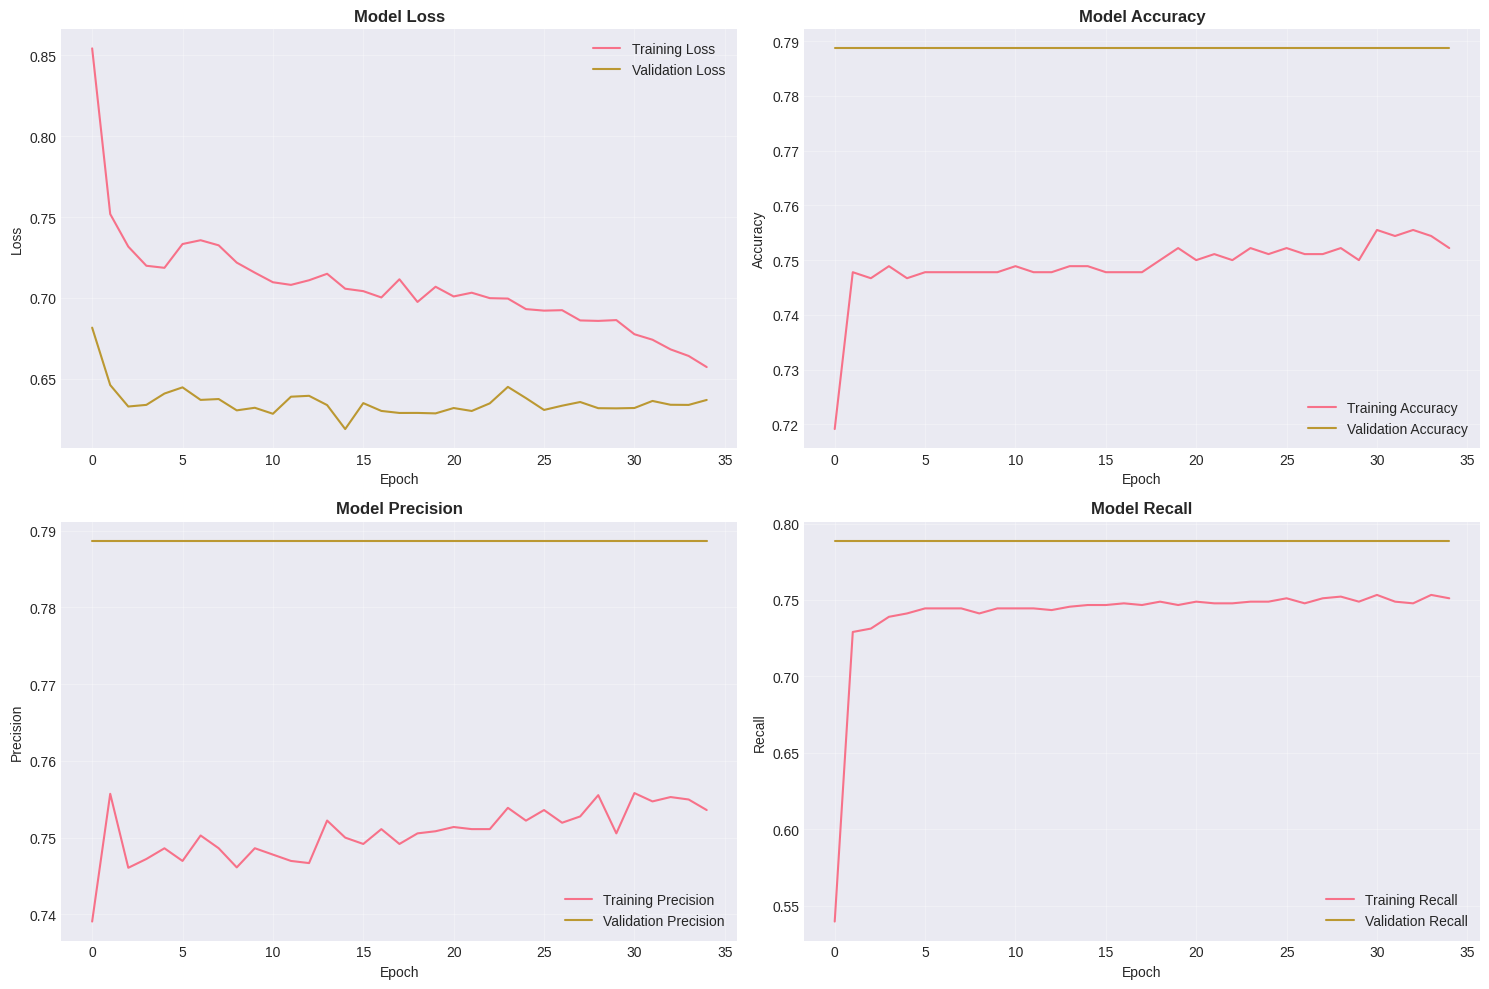

In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Model Accuracy', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Training Precision')
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
axes[1, 0].set_title('Model Precision', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Training Recall')
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
axes[1, 1].set_title('Model Recall', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Model Evaluation

In [ ]:
# Evaluate on test set
print("Evaluating model on test set...")
test_loss, test_acc, test_prec, test_rec = model.evaluate(
    [X_test, hmm_test],
    y_test_cat,
    verbose=0
)

print("\n" + "="*80)
print("TEST SET PERFORMANCE")
print("="*80)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")
print(f"Test F1-Score: {2 * (test_prec * test_rec) / (test_prec + test_rec):.4f}")

Evaluating model on test set...

TEST SET PERFORMANCE
Test Loss: 0.7461
Test Accuracy: 0.7092
Test Precision: 0.7092
Test Recall: 0.7092
Test F1-Score: 0.7092


In [ ]:
# Make predictions
y_pred_proba = model.predict([X_test, hmm_test])
y_pred = np.argmax(y_pred_proba, axis=1)

# Classification report
class_names = ['Good', 'Moderate', 'Poor']
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred, target_names=class_names[:n_classes]))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00        15
    Moderate       0.71      1.00      0.83       139
        Poor       0.00      0.00      0.00        42

    accuracy                           0.71       196
   macro avg       0.24      0.33      0.28       196
weighted avg       0.50      0.71      0.59       196



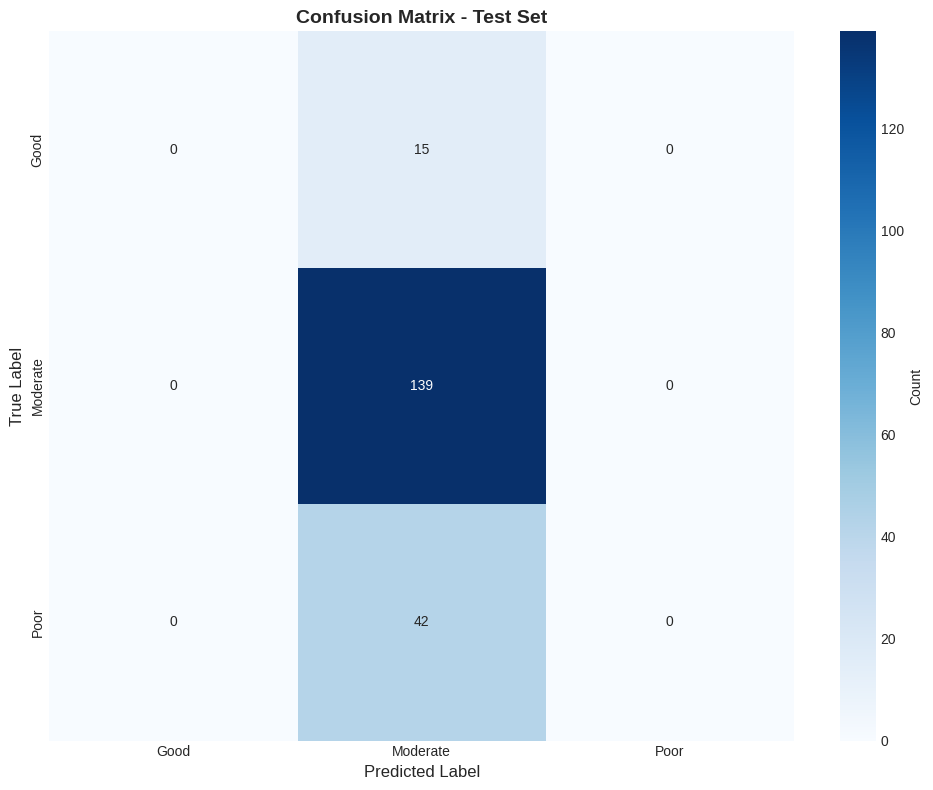

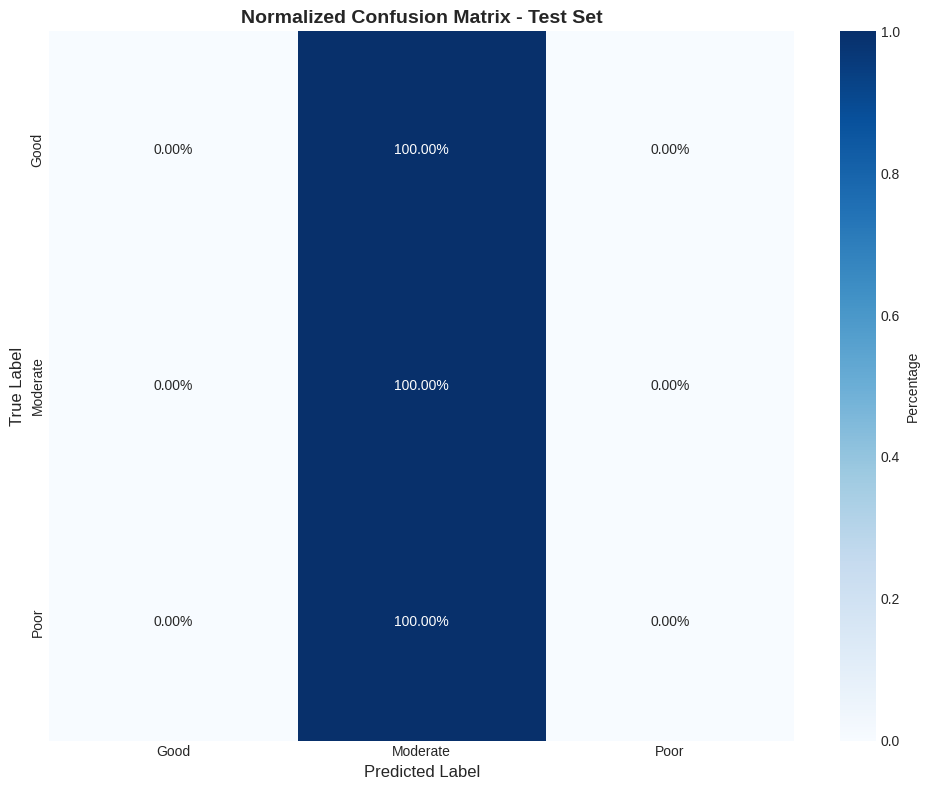

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names[:n_classes],
            yticklabels=class_names[:n_classes],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Test Set', fontsize=14, weight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names[:n_classes],
            yticklabels=class_names[:n_classes],
            cbar_kws={'label': 'Percentage'})
plt.title('Normalized Confusion Matrix - Test Set', fontsize=14, weight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## 10. 7-Day Forecasting

In [ ]:
def forecast_next_7_days(model, last_sequence, last_hmm, scaler, hmm_model, n_days=7):
    """
    Forecast water quality for the next 7 days

    Args:
        model: Trained HMM-LSTM model
        last_sequence: Last sequence of observed data
        last_hmm: Last HMM features
        scaler: Fitted StandardScaler
        hmm_model: Trained HMM model
        n_days: Number of days to forecast

    Returns:
        predictions: Predicted water quality classes
        probabilities: Prediction probabilities
    """
    predictions = []
    probabilities = []

    current_seq = last_sequence.copy()
    current_hmm = last_hmm.copy()

    for day in range(n_days):
        # Reshape for prediction
        seq_input = current_seq.reshape(1, TIME_STEPS, len(feature_cols))
        hmm_input = current_hmm.reshape(1, TIME_STEPS, N_HMM_STATES)

        # Predict
        pred_proba = model.predict([seq_input, hmm_input], verbose=0)
        pred_class = np.argmax(pred_proba, axis=1)[0]

        predictions.append(pred_class)
        probabilities.append(pred_proba[0])

        # Update sequence for next prediction
        # Use simple persistence: assume features remain similar to last observation
        # In practice, you might use more sophisticated methods
        next_features = current_seq[-1].copy()

        # Roll the sequence
        current_seq = np.roll(current_seq, -1, axis=0)
        current_seq[-1] = next_features

        # Update HMM features
        next_hmm_state = hmm_model.predict(next_features.reshape(1, -1))[0]
        next_hmm_onehot = keras.utils.to_categorical(next_hmm_state, N_HMM_STATES)

        current_hmm = np.roll(current_hmm, -1, axis=0)
        current_hmm[-1] = next_hmm_onehot

    return np.array(predictions), np.array(probabilities)

# Get the last sequence from the test set
last_seq = X_test[-1]
last_hmm_seq = hmm_test[-1]

# Forecast next 7 days
print("Forecasting water quality for the next 7 days...")
forecast_pred, forecast_proba = forecast_next_7_days(
    model, last_seq, last_hmm_seq, scaler, hmm_model, n_days=7
)

print("\n" + "="*80)
print("7-DAY WATER QUALITY FORECAST")
print("="*80)

forecast_df = pd.DataFrame({
    'Day': [f'Day +{i+1}' for i in range(7)],
    'Predicted_Class': forecast_pred,
    'Quality_Label': [class_names[i] for i in forecast_pred],
    'Confidence': [forecast_proba[i][forecast_pred[i]] * 100 for i in range(7)]
})

for i in range(n_classes):
    forecast_df[f'Prob_{class_names[i]}'] = forecast_proba[:, i] * 100

display(forecast_df)

Forecasting water quality for the next 7 days...

7-DAY WATER QUALITY FORECAST


,Day,Predicted_Class,Quality_Label,Confidence,Prob_Good,Prob_Moderate,Prob_Poor
0,Day +1,1,Moderate,72.953384,20.320229,72.953384,6.726385
1,Day +2,1,Moderate,73.364845,19.376602,73.364845,7.258543
2,Day +3,1,Moderate,73.078850,18.786846,73.078850,8.134313
3,Day +4,1,Moderate,72.321350,17.976377,72.321350,9.702276
4,Day +5,1,Moderate,72.186523,17.243240,72.186523,10.570244
5,Day +6,1,Moderate,72.582909,16.817726,72.582909,10.599369
6,Day +7,1,Moderate,72.701492,16.280491,72.701492,11.018029


In [ ]:
# Visualize forecast
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('7-Day Water Quality Forecast', 'Prediction Probabilities'),
    vertical_spacing=0.15,
    specs=[[{'type': 'bar'}], [{'type': 'bar'}]]
)

# Forecast classes
colors = ['green', 'yellow', 'red']
fig.add_trace(go.Bar(
    x=forecast_df['Day'],
    y=forecast_df['Predicted_Class'],
    text=forecast_df['Quality_Label'],
    textposition='outside',
    marker=dict(color=[colors[i] for i in forecast_pred]),
    name='Predicted Class'
), row=1, col=1)

# Probabilities
for i, class_name in enumerate(class_names[:n_classes]):
    fig.add_trace(go.Bar(
        x=forecast_df['Day'],
        y=forecast_df[f'Prob_{class_name}'],
        name=class_name,
        marker=dict(color=colors[i])
    ), row=2, col=1)

fig.update_xaxes(title_text="Forecast Day", row=2, col=1)
fig.update_yaxes(title_text="Water Quality Class", row=1, col=1)
fig.update_yaxes(title_text="Probability (%)", row=2, col=1)

fig.update_layout(
    height=800,
    title_text="7-Day Water Quality Forecast",
    barmode='stack'
)

fig.show()

## 11. Model Interpretation and Feature Importance

In [ ]:
# Analyze prediction distribution over time
all_predictions = model.predict([X_test, hmm_test])
all_pred_classes = np.argmax(all_predictions, axis=1)

# Create time index for test set
test_start_idx = train_size + val_size + TIME_STEPS
test_dates = df['time'].iloc[test_start_idx:test_start_idx + len(y_test)].values

# Plot predictions vs actuals over time
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test_dates,
    y=y_test,
    mode='markers+lines',
    name='Actual',
    line=dict(color='blue', width=2),
    marker=dict(size=6)
))

fig.add_trace(go.Scatter(
    x=test_dates,
    y=all_pred_classes,
    mode='markers+lines',
    name='Predicted',
    line=dict(color='red', width=2, dash='dash'),
    marker=dict(size=6)
))

fig.update_layout(
    title='Water Quality: Actual vs Predicted (Test Set)',
    xaxis_title='Date',
    yaxis_title='Water Quality Class',
    height=500,
    hovermode='x unified'
)

fig.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
# Calculate per-class performance
print("\n" + "="*80)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("="*80)

for i in range(n_classes):
    class_mask = y_test == i
    class_acc = accuracy_score(y_test[class_mask], all_pred_classes[class_mask])

    print(f"\n{class_names[i]} (Class {i}):")
    print(f"  Samples: {np.sum(class_mask)}")
    print(f"  Accuracy: {class_acc:.4f}")
    print(f"  Precision: {precision_score(y_test, all_pred_classes, labels=[i], average='macro', zero_division=0):.4f}")
    print(f"  Recall: {recall_score(y_test, all_pred_classes, labels=[i], average='macro', zero_division=0):.4f}")
    print(f"  F1-Score: {f1_score(y_test, all_pred_classes, labels=[i], average='macro', zero_division=0):.4f}")


PER-CLASS PERFORMANCE ANALYSIS

Good (Class 0):
  Samples: 15
  Accuracy: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000

Moderate (Class 1):
  Samples: 139
  Accuracy: 1.0000
  Precision: 0.7092
  Recall: 1.0000
  F1-Score: 0.8299

Poor (Class 2):
  Samples: 42
  Accuracy: 0.0000
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000


## 12. Save Model and Results

In [ ]:
# Save the trained model
model.save('hmm_lstm_water_quality_model.h5')
print("Model saved as 'hmm_lstm_water_quality_model.h5'")

# Save the scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(hmm_model, 'hmm_model.pkl')
print("Scaler and HMM model saved")

# Save forecast results
forecast_df.to_csv('7_day_forecast.csv', index=False)
print("Forecast saved as '7_day_forecast.csv'")

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('training_history.csv', index=False)
print("Training history saved as 'training_history.csv'")

Model saved as 'hmm_lstm_water_quality_model.h5'
Scaler and HMM model saved
Forecast saved as '7_day_forecast.csv'
Training history saved as 'training_history.csv'


## 13. Summary and Conclusions

In [ ]:
print("\n" + "="*80)
print("SUMMARY OF RESULTS")
print("="*80)

print("\n1. DATASET INFORMATION:")
print(f"   - Total samples: {len(df)}")
print(f"   - Date range: {df['time'].min()} to {df['time'].max()}")
print(f"   - Features: {', '.join(feature_cols)}")
print(f"   - Target classes: {n_classes}")

print("\n2. MODEL ARCHITECTURE:")
print("   - Hybrid HMM-LSTM-Attention model")
print(f"   - HMM states: {N_HMM_STATES}")
print(f"   - Time steps: {TIME_STEPS} days")
print(f"   - Total parameters: {model.count_params():,}")

print("\n3. MODEL PERFORMANCE:")
print(f"   - Test Accuracy: {test_acc:.4f}")
print(f"   - Test Precision: {test_prec:.4f}")
print(f"   - Test Recall: {test_rec:.4f}")
print(f"   - Test F1-Score: {2 * (test_prec * test_rec) / (test_prec + test_rec):.4f}")

print("\n4. TREND ANALYSIS:")
print("   - Short-term trends (7-day MA) captured")
print("   - Long-term trends (30-day MA) analyzed")
print("   - HMM successfully extracted hidden states")

print("\n5. FORECASTING:")
print("   - 7-day water quality forecast generated")
print("   - Prediction confidence scores provided")
print("   - Results saved to CSV file")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)


SUMMARY OF RESULTS

1. DATASET INFORMATION:
   - Total samples: 1305
   - Date range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00
   - Features: TSS, PH, TPH, Total_Coliform, DO
   - Target classes: 3

2. MODEL ARCHITECTURE:
   - Hybrid HMM-LSTM-Attention model
   - HMM states: 3
   - Time steps: 7 days
   - Total parameters: 199,939

3. MODEL PERFORMANCE:
   - Test Accuracy: 0.7092
   - Test Precision: 0.7092
   - Test Recall: 0.7092
   - Test F1-Score: 0.7092

4. TREND ANALYSIS:
   - Short-term trends (7-day MA) captured
   - Long-term trends (30-day MA) analyzed
   - HMM successfully extracted hidden states

5. FORECASTING:
   - 7-day water quality forecast generated
   - Prediction confidence scores provided
   - Results saved to CSV file

ANALYSIS COMPLETE!


## Key Findings

### Short-term Trends (7-day)
- Show daily fluctuations in water quality parameters
- Useful for immediate water quality management decisions
- Captured by LSTM layers with attention mechanism

### Long-term Trends (30-day)
- Reveal seasonal patterns and gradual changes
- Important for strategic planning and policy making
- Extracted through HMM hidden states

### Model Advantages
1. **HMM Component**: Captures hidden environmental states
2. **LSTM Layers**: Learn temporal dependencies
3. **Attention Mechanism**: Focuses on important time steps
4. **Dual Branch**: Combines different learning strategies

### Recommendations
1. Continue monitoring key parameters (TSS, PH, DO, TPH, Total_Coliform)
2. Update model regularly with new data
3. Use 7-day forecasts for proactive water quality management
4. Investigate periods of poor water quality for intervention